# FePc Layer on Ag(001)
Ordered 3x3 FePc molecular layer (1.5 nm spacing) on Ag(100) with one step edge.


In [20]:
import sys
from pathlib import Path

repo_root = Path(r'C:\\Users\\phili\\Documents\\Github\\stm-topography-sim')
sys.path.insert(0, str(repo_root))

import numpy as np
import matplotlib.pyplot as plt

from stm_sim.config import SimulationConfig
from stm_sim.simulator import build_scene_from_config
from stm_sim.utils import ensure_rng, grid_from_bbox, rotation_matrix_z
from stm_sim.geometry import add_molecule_lattice, plot_scene_top_view, plot_scene_3d
from stm_sim.stm import solve_constant_current
from stm_sim.noise import apply_noise
from stm_sim.labels import generate_mask

%reload_ext autoreload
%autoreload 2


In [21]:
# Scene config: Ag(100), 20 nm, 1 step, a few adatoms & vacancies
cfg = SimulationConfig(seed=42)
cfg.surface.surface = '100'
cfg.surface.size_angstrom = (120.0, 120.0)  # 20 nm
cfg.features.step_probability = 1.0
cfg.features.step_height_layers = 1
cfg.features.adatom_count = (3, 6)
cfg.features.vacancy_count = (2, 4)
cfg.features.molecule_count = (0, 0)  # we'll place a custom grid

# Optional: blur/noise
# cfg.noise.tip_sigma = (3.0, 3.0)

rng = ensure_rng(cfg.seed)
scene = build_scene_from_config(cfg, rng)
base_bbox = scene.metadata.get('surface_bbox', scene.bbox)
cfg.noise.tip_sigma = (2.0, 2.0)
cfg.stm.cutoff = 4.0
cfg.stm.solver_iters = 4


In [22]:
# Place a 3x3 ordered FePc layer (random center + spacing)
spacing = 15.0  # ? nominal (1.5 nm)
spacing_range = (12.0, 18.0)  # randomize lattice size
grid_n = 3

# Lattice parameters: initial orientation and lattice angle
orientation_deg = 0.0
lattice_angle_deg = 0.0  # rotate lattice if desired

add_molecule_lattice(
    scene,
    molecule_name='FePc',
    grid_n=grid_n,
    spacing=spacing,
    orientation_deg=orientation_deg,
    lattice_angle_deg=lattice_angle_deg,
    height=cfg.features.molecule_height,
    rng=rng,
    random_center=True,
    spacing_range=spacing_range,
    grid_range=None,
    molecule_z_scale=cfg.features.molecule_z_scale,
    molecule_xy_scale=cfg.features.molecule_xy_scale,
)

# Update bbox after adding molecules
scene.bbox = ((scene.positions[:,0].min(), scene.positions[:,0].max()),
              (scene.positions[:,1].min(), scene.positions[:,1].max()))

print('Surface atoms:', int((scene.types == 'surface').sum()))
print('Adatoms:', int((scene.types == 'adatom').sum()))
print('Molecule atoms:', int((scene.types == 'molecule').sum()))
print('Vacancies:', scene.vacancies.shape[0])
print('Step edges:', scene.step_edges)


Surface atoms: 1762
Adatoms: 3
Molecule atoms: 369
Vacancies: 2
Step edges: [{'axis': 'angle', 'position': None, 'height': 2.045, 'normal': [0.19084121908206167, 0.9816209192449357], 'point': [41.80802180141704, 22.690230036213876], 'angle_deg': 78.99811915536942}]


(<Figure size 500x500 with 1 Axes>,
 <Axes: title={'center': 'Atomic Positions (Top View)'}, xlabel='x (Å)', ylabel='y (Å)'>)

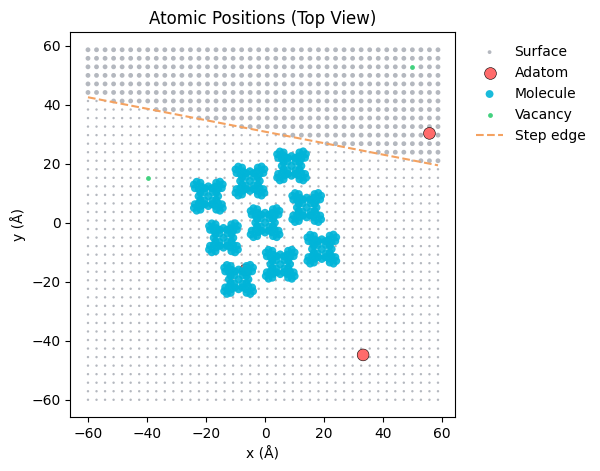

In [23]:
# 2D and 3D views
plot_scene_top_view(scene)


(<Figure size 1000x500 with 2 Axes>,
 [<Axes3D: title={'center': '3D View (elev=20, azim=35)'}, xlabel='x (Å)', ylabel='y (Å)', zlabel='z (Å)'>,
  <Axes3D: title={'center': '3D View (elev=35, azim=120)'}, xlabel='x (Å)', ylabel='y (Å)', zlabel='z (Å)'>])

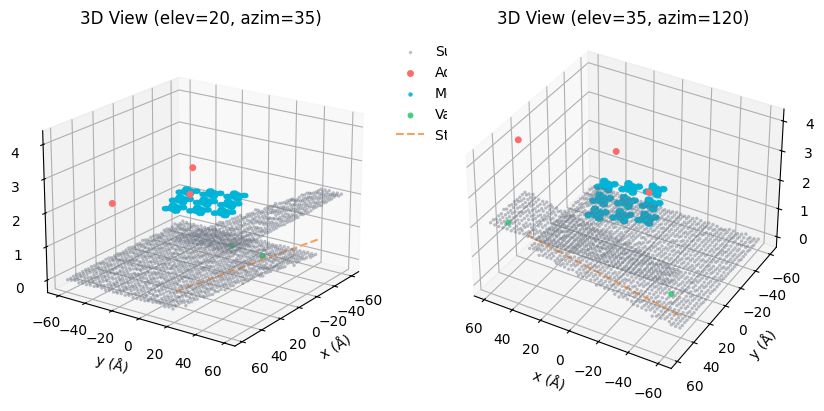

In [24]:
plot_scene_3d(scene, views=[(20, 35), (35, 120)], zlim=(-5, 8))


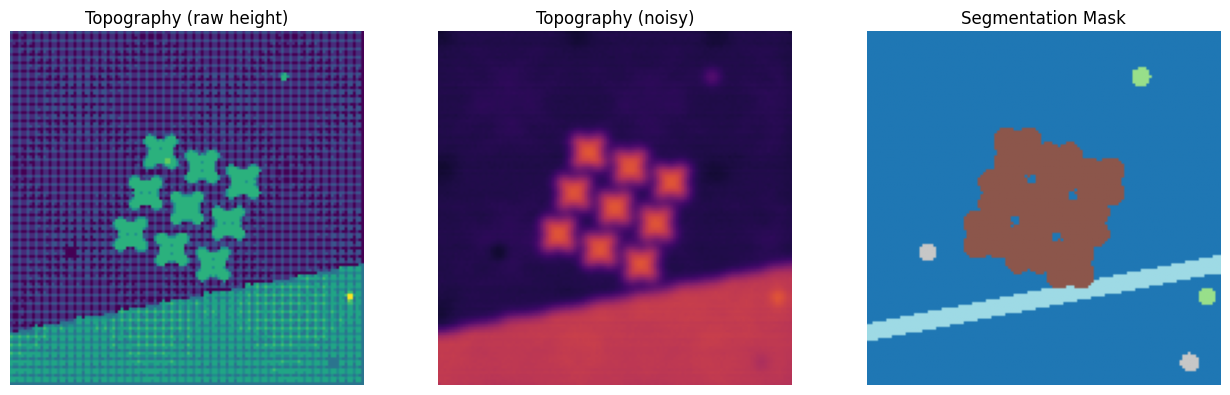

In [25]:
# Topography + mask
x, y = grid_from_bbox(base_bbox, cfg.image.pixels)
setpoint = np.mean(cfg.stm.setpoint_range)
raw_height = solve_constant_current(scene, x, y, setpoint, cfg.ldos, cfg.stm)

nx = cfg.image.pixels[1]
ny = cfg.image.pixels[0]
dx = (base_bbox[0][1] - base_bbox[0][0]) / max(1, nx - 1)
dy = (base_bbox[1][1] - base_bbox[1][0]) / max(1, ny - 1)
image = apply_noise(raw_height, cfg.noise, rng, pixel_size=(dx, dy))
blur_radius = float(np.mean(cfg.noise.tip_sigma))
mask = generate_mask(scene, cfg.image.pixels, cfg.labels, bbox=base_bbox, blur_radius=blur_radius)

vmin, vmax = float(raw_height.min()), float(raw_height.max())
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(raw_height, cmap='viridis', vmin=vmin, vmax=vmax)
axes[0].set_title('Topography (raw height)')
axes[0].axis('off')

axes[1].imshow(image, cmap='inferno', vmin=vmin, vmax=vmax)
axes[1].set_title('Topography (noisy)')
axes[1].axis('off')

axes[2].imshow(mask, cmap='tab20')
axes[2].set_title('Segmentation Mask')
axes[2].axis('off')

plt.tight_layout()


In [3]:
!pip install tifffile

!python ../scripts/generate_fepc_layer.py --out dataset_fepc_layer8 --n 20 --orientation 20 --lattice_angle 10 --spacing 15 --grid_range 1 6 --seed 55 --spacing_range 15 15


^C


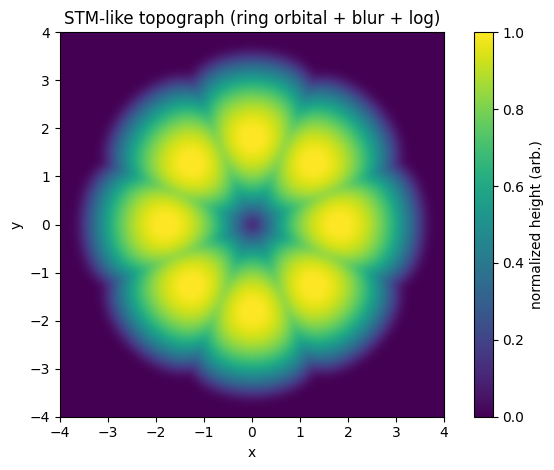

In [36]:
import numpy as np
import matplotlib.pyplot as plt

# --- Grid ---
N = 600
L = 4.0
x = np.linspace(-L, L, N)
y = np.linspace(-L, L, N)
X, Y = np.meshgrid(x, y)
r = np.sqrt(X**2 + Y**2)
theta = np.arctan2(Y, X)

# --- Ring orbital parameters (tune these) ---
r0 = 1.8       # ring radius (in your length units)
sig_r = 0.45   # ring thickness
ang_mix = 0.0  # set ~0.1..0.3 if you want slightly "squared" lobes

# --- STM-ish parameters ---
kappa = 10.0
eps = 1e-6
sigma_tip = 0.15

# --- Wavefunction: ring-localized 8-lobe ---
psi1 = np.exp(-0.5 * ((r - r0) / sig_r)**2) * np.cos(4 * theta)

# Optional: add a weak higher harmonic to fatten the mid-lobes slightly
# (keeps C4 symmetry but changes lobe shape)
psi2 = np.exp(-0.5 * ((r - r0) / sig_r)**2) * np.cos(8 * theta)
psi = psi1 + ang_mix * psi2

rho = psi**2
rho /= rho.max()

# --- Gaussian blur via FFT ---
dx = x[1] - x[0]
kx = np.fft.fftfreq(N, d=dx)
ky = np.fft.fftfreq(N, d=dx)
KX, KY = np.meshgrid(kx, ky)
gauss_ft = np.exp(-2 * (np.pi**2) * (sigma_tip**2) * (KX**2 + KY**2))

rho_blur = np.real(np.fft.ifft2(np.fft.fft2(rho) * gauss_ft))
rho_blur = np.clip(rho_blur, 0, None)
rho_blur /= rho_blur.max()

# --- Constant-current height ---
z = (1.0 / (2 * kappa)) * np.log(rho_blur + eps)

# Display scaling (like STM contrast windowing)
z_disp = z - np.percentile(z, 1)
z_disp = np.clip(z_disp, 0, np.percentile(z_disp, 99))
z_disp /= z_disp.max()

plt.figure()
plt.imshow(z_disp, extent=[-L, L, -L, L], origin="lower")
plt.title("STM-like topograph (ring orbital + blur + log)")
plt.xlabel("x"); plt.ylabel("y")
plt.colorbar(label="normalized height (arb.)")
plt.tight_layout()
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'dataset_fepc_layer7/meta_0000.json'